# Tutorial: an analysis that can defend itself

We take a real, published experiment — [Kang et al.
2018](https://doi.org/10.1038/nbt.4042), eight lupus patients whose PBMCs were
split into control and interferon-β-stimulated halves — and run it the way
Cellimo intends: every artifact hashed, every decision recorded, and the
experimental design settled before a single p-value exists.

Then we do the one thing that matters. We record the *same* comparison the way
it is most commonly done wrong, and watch `cellimo check` refuse it.

:::{admonition} This page is a Jupyter notebook. Your analysis will not be.
:class: important

Cellimo generates a **Marimo** notebook — `analysis.py`, a plain Python file
with no hidden state and no execution order to get wrong. MyST-NB cannot execute
a Marimo notebook, so this tutorial drives the same Python API from a Jupyter
kernel.

Everything below is the API your `analysis.py` cells will call. What changes in
real use is the surroundings: Marimo owns the kernel, and Codex or Claude Code
writes the cells. Cellimo behaves identically either way, and never calls a
language model itself.
:::

:::{note}
Unlike the rest of this site, this page is **executed locally** and its outputs
are committed, because it downloads a real dataset and runs a full analysis.
Re-run it with `make -C docs execute`.
:::

## 1. The data, before we touch it

Eight patients. Each contributes both a control and a stimulated sample, so the
design is *paired* — which is exactly the structure that gets thrown away when
someone tests 24,000 cells as if they were 24,000 independent observations.

In [1]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc

sc.settings.verbosity = 1
# pertpy downloads through scanpy's dataset directory, which defaults to ./data
# — that is, into whatever directory you happened to run from. Pin it, so the
# 38 MB file is cached once somewhere predictable and never lands in the repo.
sc.settings.datasetdir = Path.home() / ".cache" / "cellimo-docs-data"

adata = pt.data.kang_2018()
adata.X = adata.X.tocsr()          # shipped as CSC; scanpy wants CSR
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [2]:
# `replicate` is the donor, `label` is the condition. Neither is named the way
# you would guess, which is the first reason Cellimo audits rather than assumes.
pd.crosstab(adata.obs["replicate"], adata.obs["label"])

label,ctrl,stim
replicate,,
patient_101,858,1166
patient_107,517,525
patient_1015,2738,2352
patient_1016,1723,1635
patient_1039,461,641
patient_1244,1879,1464
patient_1256,2108,2026
patient_1488,2031,2549


Every donor appears in both arms: **8 biological replicates per condition**, not
four. That number — 8, not 24,673 — is the one every statistical claim below
has to answer to.

Cellimo needs a *sample*: the unit that was processed together, and the unit
quality control must be stratified by. Here that is a donor–condition pair.

In [3]:
adata.obs["sample_id"] = (
    adata.obs["replicate"].astype(str) + "_" + adata.obs["label"].astype(str)
)
print(adata.obs["sample_id"].nunique(), "samples from",
      adata.obs["replicate"].nunique(), "donors")

16 samples from 8 donors


## 2. Initialise the project

The dataset is hashed **where it lies**. Cellimo never copies, moves or writes to
it: the source is the root of every lineage chain and is immutable through every
API on this page.

In [4]:
import tempfile
from pathlib import Path

from cellimo.project.project import Project

root = Path(tempfile.mkdtemp(prefix="cellimo-kang-"))
(root / "data").mkdir()
source = root / "data" / "kang2018.h5ad"
adata.write_h5ad(source)

project = Project.init(root, source, profile="scanpy", name="kang2018")
print("project :", project.root)
print("source  :", project.config.source.sha256[:16], "…")
print("notebook:", project.notebook_path.name)

project : /tmp/cellimo-kang-z_km3nxf
source  : 33226e54d18a7b2d …
notebook: analysis.py


## 3. Audit before assuming

This is the step that catches a "raw counts" object someone normalised upstream
three months ago — and, here, something more interesting.

In [5]:
audit = project.audit_anndata(backed=True)

print(f"{audit.n_obs:,} cells x {audit.n_vars:,} genes")
print("raw counts   :", audit.raw_counts.available, "in", audit.raw_counts.location)
print("donor guess  :", audit.best_candidate("donor"))
print("sample guess :", audit.best_candidate("sample"))

24,673 cells x 15,706 genes
raw counts   : True in X
donor guess  : None
sample guess : sample_id


In [6]:
# The textbook QC metric for this data type is the mitochondrial fraction.
# Check that the genes are actually there before building a threshold on them.
mito = [g for g in adata.var_names if str(g).upper().startswith("MT-")]
print("mitochondrial genes in this object:", len(mito))

mitochondrial genes in this object: 0


None. This distribution of Kang has had them removed, so a percent-mitochondrial
threshold here would compute `0.0` for every cell and *look* like a pristine
dataset that passed a filter it never had.

That is a decision, not a detail, so it gets written down rather than discovered
by the next reader.

In [7]:
project.record_decision(
    kind="note",
    stage="post_qc",
    summary="No mitochondrial filter applied",
    rationale=(
        "The published Kang 2018 distribution contains no MT- genes, so a "
        "mitochondrial-fraction threshold cannot be computed and its absence "
        "must not be read as the cells having passed one. QC uses detected "
        "genes and total counts instead."
    ),
    actor="user",
)
print("recorded")

recorded


## 4. Declare the experimental unit — and have a human approve it

The gate the whole design turns on. A confirmatory p-value without a declared
unit of replication is uninterpretable, so Cellimo refuses to record one until a
design exists *and* someone approved it.

In [8]:
design = project.record_design(
    sample="sample_id",
    donor="replicate",
    condition="label",
)
print("status           :", design.status)
print("experimental unit:", design.experimental_unit)

status           : proposed
experimental unit: replicate


In [9]:
from cellimo.errors import DesignError

try:
    project.record_statistics(
        name="stim vs ctrl", test="pseudobulk", mode="confirmatory"
    )
except DesignError as exc:
    print("refused:", exc)

refused: cannot record a confirmatory analysis: the experimental design is not approved. Declare the design, name the biological replicate, and approve it (or record an explicit autonomous authorisation) first.


In [10]:
approved = project.approve_design(approved_by="the analyst", actor="user")
print(approved.status, "by", approved.approved_by)

approved by the analyst


:::{note}
`actor="user"` records who *made the call*. It defaults to `"agent"`, because
nothing in a library can verify a human was present — and check `C002` reports an
approval whose actor was not a user. Cellimo reports what was recorded; it does
not pretend to know more.
:::

## 5. Quality control, stratified by sample

Ordinary scanpy — the same calls the generated `analysis.py` makes. Cellimo does
not run it, wrap it or hide it. It records what came out.

In [11]:
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=False, percent_top=None)
adata.obs[["n_genes_by_counts", "total_counts"]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_genes_by_counts,24673.0,574.900985,206.621105,12.0,441.0,519.0,652.0,2757.0
total_counts,24673.0,1567.192627,912.257385,562.0,975.0,1246.0,1816.0,11816.0


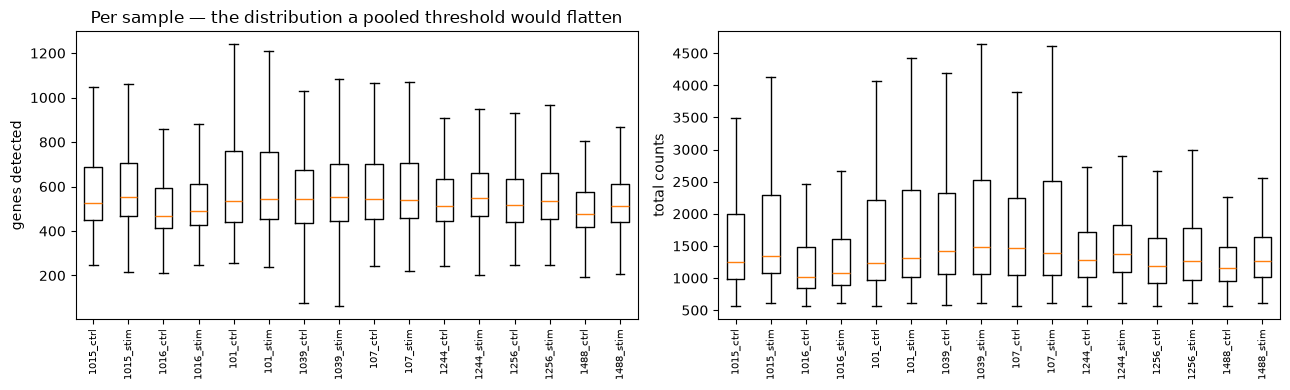

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, label in (
    (axes[0], "n_genes_by_counts", "genes detected"),
    (axes[1], "total_counts", "total counts"),
):
    order = sorted(adata.obs["sample_id"].unique())
    ax.boxplot([adata.obs.loc[adata.obs["sample_id"] == s, metric] for s in order],
               showfliers=False)
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels([s.replace("patient_", "") for s in order],
                       rotation=90, fontsize=7)
    ax.set_ylabel(label)
axes[0].set_title("Per sample — the distribution a pooled threshold would flatten")
fig.tight_layout()
plt.show()

Those distributions differ by sample. A single threshold chosen on the pooled
mixture can look reasonable and still remove most of one donor — which is what
check `C008` exists to catch, and why the exclusion below is recorded
**per sample** rather than as one number.

In [13]:
MIN_GENES, MIN_CELLS = 200, 3

keep = adata.obs["n_genes_by_counts"] >= MIN_GENES
removed_per_sample = (
    adata.obs.loc[~keep, "sample_id"].value_counts().reindex(
        sorted(adata.obs["sample_id"].unique()), fill_value=0
    ).astype(int).to_dict()
)
filtered = adata[keep.to_numpy()].copy()
sc.pp.filter_genes(filtered, min_cells=MIN_CELLS)

print(f"cells {adata.n_obs:,} -> {filtered.n_obs:,}")
print(f"genes {adata.n_vars:,} -> {filtered.n_vars:,}")
print("removed per sample:", {k: v for k, v in removed_per_sample.items() if v})

cells 24,673 -> 24,562
genes 15,706 -> 15,701
removed per sample: {'patient_1039_ctrl': 53, 'patient_1039_stim': 57, 'patient_1488_ctrl': 1}


In [14]:
filtered.layers["counts"] = filtered.X.copy()   # keep the counts before we transform

with project.stage(
    "post_qc",
    summary="Sample-stratified quality control",
    parent_sha256=project.config.source.sha256,
    params={"min_genes": MIN_GENES, "min_cells": MIN_CELLS},
) as stage:
    filtered.write_h5ad(stage.output("artifacts/post_qc.h5ad"))
    stage.add_exclusion(
        f"fewer than {MIN_GENES} genes detected",
        axis="obs",
        n_before=int(adata.n_obs),
        n_removed=int(adata.n_obs) - int(filtered.n_obs),
        n_remaining=int(filtered.n_obs),
        by_sample=removed_per_sample,
        stratified_by="sample_id",
        criteria={"min_genes": MIN_GENES},
    )
    stage.add_exclusion(
        f"detected in fewer than {MIN_CELLS} cells",
        axis="var",
        n_before=int(adata.n_vars),
        n_removed=int(adata.n_vars) - int(filtered.n_vars),
        n_remaining=int(filtered.n_vars),
    )
    stage.set_matrix_facts(
        representation="raw_counts",
        counts_layer="counts",
        raw_counts_available=True,
        n_obs=int(filtered.n_obs),
        n_vars=int(filtered.n_vars),
        obs_keys=list(filtered.obs.columns),
        layers=list(filtered.layers.keys()),
    )

post_qc = stage.descriptor
print("stage :", post_qc.stage, "|", post_qc.sha256[:16], "…")
print("parent:", post_qc.parent_sha256[:16], "… (the source)")

stage : post_qc | 633ae1d3a15064c4 …
parent: 33226e54d18a7b2d … (the source)


The source really is immutable — not by convention, but because the write guard
refuses:

In [15]:
from cellimo.errors import SourceImmutabilityError

try:
    project.assert_writable("data/kang2018.h5ad")
except SourceImmutabilityError as exc:
    print("refused:", exc)

refused: refusing to write data/kang2018.h5ad: it is the registered source dataset (/tmp/cellimo-kang-z_km3nxf/data/kang2018.h5ad), which is immutable


:::{warning}
That guard covers writes **through Cellimo's APIs**. Arbitrary Python in a
notebook cell can still open the file and overwrite it. See [](SAFETY.md) — the
honest boundary matters more than a reassuring one.
:::

## 6. Normalisation

`representation` is not decoration. It is the field check `C006` reads to decide
whether a confirmatory test ran on values it should never have touched.

In [16]:
sc.pp.normalize_total(filtered, target_sum=1e4)
sc.pp.log1p(filtered)
sc.pp.highly_variable_genes(filtered, n_top_genes=2000, batch_key="sample_id")
sc.pp.pca(filtered, n_comps=30, mask_var="highly_variable")

with project.stage(
    "normalized",
    summary="CP10K, log1p, 2000 HVGs, 30 PCs",
    parent_sha256=post_qc.sha256,
    params={"target_sum": 10000, "n_top_genes": 2000, "n_comps": 30},
) as stage:
    filtered.write_h5ad(stage.output("artifacts/normalized.h5ad"))
    stage.set_matrix_facts(
        representation="lognorm",
        counts_layer="counts",
        raw_counts_available=True,
        n_obs=int(filtered.n_obs),
        n_vars=int(filtered.n_vars),
        obsm_keys=list(filtered.obsm.keys()),
        layers=list(filtered.layers.keys()),
    )

normalized = stage.descriptor
print(normalized.stage, normalized.sha256[:16], "…")

normalized a9efd02b022ccd73 …


## 7. Clustering, and a judgement call worth recording

Kang ships the authors' own cell-type labels. We cluster from scratch anyway —
not to replace them, but because *how well an unsupervised clustering agrees with
published labels* is a real check on the pipeline, and the answer is a decision
someone should be able to look up later.

In [17]:
sc.pp.neighbors(filtered, n_neighbors=15, n_pcs=30)
sc.tl.leiden(filtered, resolution=0.5, key_added="leiden", flavor="igraph", n_iterations=2)
sc.tl.umap(filtered)
print(filtered.obs["leiden"].nunique(), "clusters")

14 clusters


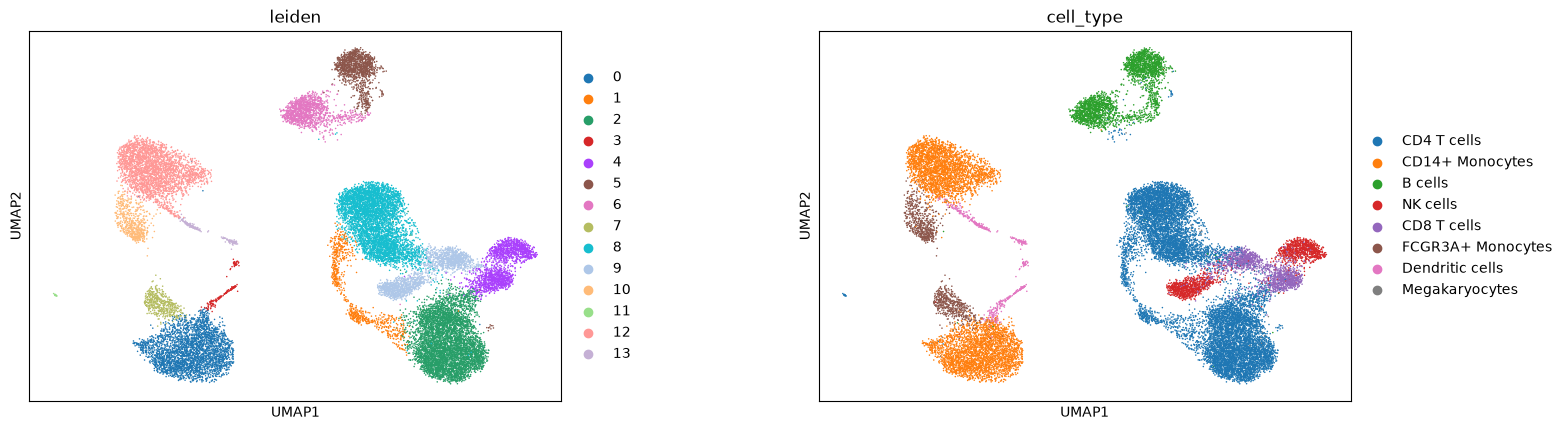

In [18]:
sc.pl.umap(filtered, color=["leiden", "cell_type"], wspace=0.35, show=False)
plt.show()

In [19]:
# Agreement between our clusters and the published annotation.
agreement = pd.crosstab(filtered.obs["leiden"], filtered.obs["cell_type"])
purity = (agreement.max(axis=1) / agreement.sum(axis=1))
print(f"median cluster purity vs published labels: {purity.median():.2f}")
agreement

median cluster purity vs published labels: 0.98


cell_type,CD4 T cells,CD14+ Monocytes,B cells,NK cells,CD8 T cells,FCGR3A+ Monocytes,Dendritic cells,Megakaryocytes
leiden,,,,,,,,
0,6,2937,3,2,0,54,76,1
1,749,0,0,0,0,0,0,0
2,5257,0,3,1,32,0,0,8
3,0,0,0,0,0,0,181,0
4,77,0,1,867,802,0,0,0
5,24,0,1322,1,0,0,0,1
6,32,1,1314,0,0,0,0,0
7,0,6,0,1,0,461,0,1
8,4912,0,3,0,19,0,0,10


In [20]:
project.record_decision(
    kind="annotation",
    stage="annotated",
    summary="Kept the published cell_type labels for the comparison",
    rationale=(
        f"Leiden at resolution 0.5 gives {filtered.obs['leiden'].nunique()} "
        f"clusters with median purity {purity.median():.2f} against the authors' "
        "annotation, so the clustering reproduces the published structure rather "
        "than contradicting it. The published labels are used downstream because "
        "they are what the original analysis reported, and re-annotating would "
        "make this analysis harder, not easier, to compare against it."
    ),
    parameters={"resolution": 0.5, "n_clusters": int(filtered.obs["leiden"].nunique())},
    actor="user",
)
print("recorded")

recorded


Now the plot that makes the whole argument visible.

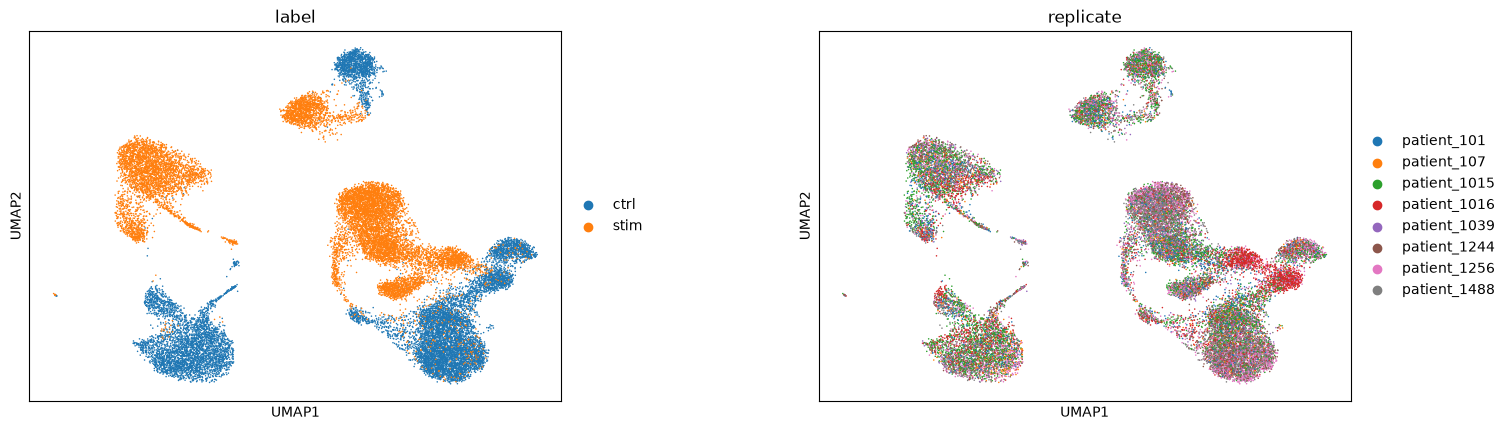

In [21]:
sc.pl.umap(filtered, color=["label", "replicate"], wspace=0.35, show=False)
plt.show()

Stimulation moves the cells; donors are smeared across every cluster. Cells from
one donor are not independent observations of the *condition* — they are repeated
measurements of that donor. Any test that treats them as independent is
answering a question nobody asked.

In [22]:
with project.stage(
    "annotated",
    summary="Leiden clustering; published cell_type labels retained",
    parent_sha256=normalized.sha256,
    params={"resolution": 0.5},
) as stage:
    filtered.write_h5ad(stage.output("artifacts/annotated.h5ad"))
    stage.set_matrix_facts(
        representation="lognorm",
        counts_layer="counts",
        raw_counts_available=True,
        n_obs=int(filtered.n_obs),
        n_vars=int(filtered.n_vars),
        obs_keys=list(filtered.obs.columns),
        layers=list(filtered.layers.keys()),
    )

annotated = stage.descriptor
print(annotated.stage, annotated.sha256[:16], "…")

annotated 3a7ed224c695149f …


## 8. Pseudobulk

Cellimo has no `pseudobulk()` helper, deliberately. The aggregation is ordinary
pandas you can read and check; Cellimo's job is to record *that it happened* and
what it produced.

We take CD14+ monocytes, where the interferon response is strongest, and sum
raw counts within each donor–condition pair. Sixteen columns. Eight pairs.

In [23]:
CELL_TYPE = "CD14+ Monocytes"
subset = filtered[filtered.obs["cell_type"] == CELL_TYPE]
counts = subset.layers["counts"]

groups = subset.obs[["replicate", "label"]].astype(str).agg("|".join, axis=1)
order = sorted(groups.unique())
pseudobulk = np.vstack([
    np.asarray(counts[(groups == g).to_numpy()].sum(axis=0)).ravel() for g in order
])
pb = pd.DataFrame(pseudobulk, index=order, columns=subset.var_names)
print(pb.shape, "= (donor x condition) x genes")
pb.iloc[:4, :4]

(16, 15701) = (donor x condition) x genes


index,AL627309.1,RP11-206L10.2,RP11-206L10.9,FAM87B
patient_1015|ctrl,0.0,0.0,0.0,0.0
patient_1015|stim,0.0,0.0,0.0,0.0
patient_1016|ctrl,0.0,1.0,0.0,0.0
patient_1016|stim,0.0,0.0,0.0,1.0


## 9. The confirmatory test

DESeq2 on the summed counts, with the donor in the model: `~ donor + condition`.
The paired structure is not a footnote here — it is a term in the design
formula, which is what "respecting the replication" actually means in practice.

In [24]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

meta = pd.DataFrame(
    {"donor": [i.split("|")[0] for i in pb.index],
     "condition": [i.split("|")[1] for i in pb.index]},
    index=pb.index,
)
# Drop genes seen in fewer than half the pseudobulk samples.
pbf = pb.loc[:, (pb > 0).sum(axis=0) >= len(pb) * 0.5].round().astype(int)

dds = DeseqDataSet(counts=pbf, metadata=meta, design="~ donor + condition", quiet=True)
dds.deseq2()
stats_res = DeseqStats(dds, contrast=["condition", "stim", "ctrl"], quiet=True)
stats_res.summary()

de = stats_res.results_df.dropna(subset=["padj"])
sig = de[(de.padj < 0.05) & (de.log2FoldChange.abs() > 1)]
print()
print(f"{len(sig):,} genes at padj < 0.05 and |log2FC| > 1, of {len(de):,} tested")
sig.nlargest(8, "log2FoldChange")[["log2FoldChange", "padj"]]

/exports/para-lipg-hpc/mdmanurung/cellimo/.venv/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)



2,281 genes at padj < 0.05 and |log2FC| > 1, of 9,040 tested


,log2FoldChange,padj
index,,
CCL8,9.876198,6.426398e-112
CXCL11,9.744768,2.744865e-62
CXCL10,9.718732,5.858165e-53
IFIT1,8.641083,2.622385e-45
CCNA1,8.630495,9.404632e-16
HESX1,8.603576,8.082240e-29
IFIT2,8.567444,1.041292e-50
NUPR1,8.413445,3.917699e-23


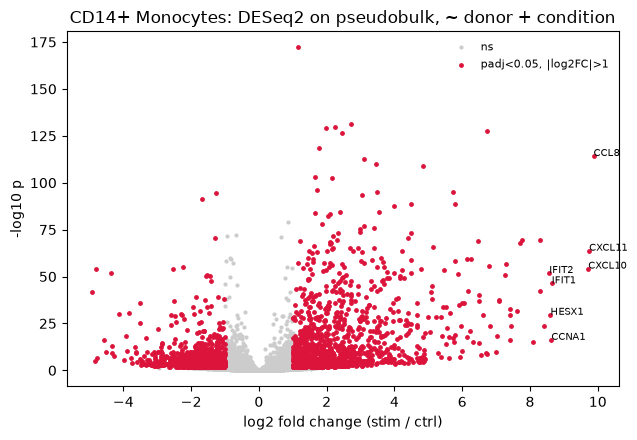

In [25]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
hit = (de.padj < 0.05) & (de.log2FoldChange.abs() > 1)
ax.scatter(de.log2FoldChange[~hit], -np.log10(de.pvalue[~hit]), s=4, c="0.8", label="ns")
ax.scatter(de.log2FoldChange[hit], -np.log10(de.pvalue[hit]), s=6, c="crimson",
           label="padj<0.05, |log2FC|>1")
for gene, r in sig.nlargest(7, "log2FoldChange").iterrows():
    ax.annotate(gene, (r.log2FoldChange, -np.log10(r.pvalue)), fontsize=7)
ax.set_xlabel("log2 fold change (stim / ctrl)")
ax.set_ylabel("-log10 p")
ax.set_title(f"{CELL_TYPE}: DESeq2 on pseudobulk, ~ donor + condition")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The strongest effects are interferon-response genes — the `CCL8`/`CXCL10`
chemokines and the `ISG`/`IFIT` families. The biology is right, which matters:
a method that respects replication and then finds nothing would be a different
kind of failure.

Ranking by fold change rather than by p-value is deliberate. With eight pairs
and a well-fitted dispersion, the smallest p-values belong to abundant,
low-variance housekeeping genes; the largest *effects* are the biology.

Now record it. These fields are not paperwork: `unit_level`, `aggregation`,
`n_units` and `input_representation` are what checks `C004`, `C005`, `C006` and
`C012` read.

In [26]:
with project.stage(
    "statistics",
    summary=f"Pseudobulk matrix for {CELL_TYPE}",
    parent_sha256=annotated.sha256,
    params={"cell_type": CELL_TYPE, "n_pseudobulk_samples": int(pb.shape[0])},
) as stage:
    pb.to_csv(stage.output("results/tables/pseudobulk.csv", kind="table"))
    stage.set_matrix_facts(
        representation="pseudobulk_counts",
        raw_counts_available=True,
        n_obs=int(pb.shape[0]),
        n_vars=int(pb.shape[1]),
    )
pb_artifact = stage.descriptor

project.record_reference(
    reference_id="doi:10.1038/s41467-021-25960-2",
    title="Confronting false discoveries in single-cell differential expression",
    source="Squair et al. 2021, Nature Communications",
    used_for="choice of pseudobulk aggregation over a cell-level test",
    stage="statistics",
)

project.record_statistics(
    name=f"{CELL_TYPE}: stim vs ctrl, pseudobulk",
    test="DESeq2 on pseudobulk, ~ donor + condition",
    mode="confirmatory",
    unit_level="donor",
    n_units={"ctrl": 8, "stim": 8},
    n_cells={"ctrl": int((subset.obs["label"] == "ctrl").sum()),
             "stim": int((subset.obs["label"] == "stim").sum())},
    groups=["ctrl", "stim"],
    input_artifact_sha256=pb_artifact.sha256,
    input_representation="pseudobulk_counts",
    aggregation="pseudobulk",
    effect_size={"reported": True, "measure": "log2FC", "column": "log2FoldChange"},
    uncertainty={"reported": True, "measure": "BH-adjusted p-value", "column": "padj"},
)
project.capture_environment()
print("recorded")

recorded


## 10. Validate

In [27]:
report = project.check()
print(report.to_text())

cellimo check: 21 checks passed for 'kang2018' — no findings.


In [28]:
for item in project.artifacts.lineage_of(pb_artifact.sha256):
    print(f"  {item.stage:11} {item.sha256[:12]}…  {item.path}")

  statistics  4d0d09bf94a4…  results/tables/pseudobulk.csv
  annotated   3a7ed224c695…  artifacts/annotated.h5ad
  normalized  a9efd02b022c…  artifacts/normalized.h5ad
  post_qc     633ae1d3a150…  artifacts/post_qc.h5ad
  source      33226e54d18a…  data/kang2018.h5ad


## 11. The part that matters: it catches you

A validator that only ever passes tells you nothing. Here is the same
comparison, in the same cell type, on the same data — run per *cell* instead of
per donor. This is the single most common error in single-cell differential
expression, and the reason this package exists.

In [29]:
project.record_statistics(
    name=f"{CELL_TYPE}: stim vs ctrl, per cell",
    test="wilcoxon",
    mode="confirmatory",
    unit_level="cell",
    n_units={"ctrl": int((subset.obs["label"] == "ctrl").sum()),
             "stim": int((subset.obs["label"] == "stim").sum())},
    groups=["ctrl", "stim"],
    input_artifact_sha256=annotated.sha256,
    input_representation="lognorm",
    aggregation="none",
    effect_size={"reported": True, "measure": "log2FC"},
    uncertainty={"reported": True, "measure": "padj"},
)

report = project.check()
for finding in report.errors:
    print(finding.format_line())
    print("   ", finding.detail)
    for ref in finding.references:
        print("    see:", ref)
print("\nexit code:", report.exit_code())

ERROR C004 [statistics:CD14+ Monocytes: stim vs ctrl, per cell]: No biological replicate is declared for a confirmatory analysis
    'CD14+ Monocytes: stim vs ctrl, per cell' is a confirmatory wilcoxon with unit_level='cell' and aggregation='none', so nothing in the record identifies an independent biological unit. Cells from one donor are not independent; without pseudobulk aggregation or a donor random effect, between-replicate variance is not estimated and false discovery is inflated. wilcoxon is a cell-level test.
    see: Squair et al. 2021, Nat Commun 12:5692, doi:10.1038/s41467-021-25960-2
    see: Zimmerman et al. 2021, Nat Commun 12:738, doi:10.1038/s41467-021-21038-1
    see: Murphy & Skene 2022, Nat Commun 13:7851, doi:10.1038/s41467-022-35519-4

exit code: 1


Note what did *not* save it. The test is called `wilcoxon`, but `C004` never
looked at the name — it read `unit_level` and `aggregation`, the structure of the
record. Renaming the test to `pseudobulk_deseq2` would change nothing. A rule you
escape by renaming a string is not a rule.

[](VALIDATION.md) has all 21 checks and the literature behind each.

In [30]:
shutil.rmtree(root, ignore_errors=True)

## Where to go next

- [](VALIDATION.md) — every check, what it reads, and the papers behind it
- [](ARCHITECTURE.md) — the two-runtime split, and why Cellimo owns no kernel
- [](SAFETY.md) — what is enforced, and the limits stated rather than implied
- [](MARIMO.md) — how this fits a live Marimo session and marimo-pair